# Diagnose SSP input differentiation

Investigates why SSP scenarios produce nearly identical CISI projections.

Checks:
1. How different are the normalized GDP/POP inputs between SSPs?
2. How different are the LC inputs between SSPs?
3. What is the pixel-level correlation between SSP1 and SSP5 inputs?
4. Which input channel drives the most variance across scenarios?

In [1]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

NORM_DIR = r'READY_data\inputs_normalized\ssp'
YEARS = [2030, 2050, 2100]
SSPS  = ['SSP1', 'SSP2', 'SSP3', 'SSP4', 'SSP5']

def load(path):
    with rasterio.open(path) as src:
        d = src.read(1).astype(np.float32)
    d[d < -1e10] = np.nan
    d[np.isinf(d)] = np.nan
    return d

print('Setup done')

Setup done


## 1. GDP: pixel-level difference between SSPs per year

In [2]:
print('GDP normalized — mean absolute difference between SSPs')
print(f'{"":10}', end='')
for ssp2 in SSPS[1:]:
    print(f'{ssp2:>12}', end='')
print()

for year in YEARS:
    print(f'\n{year}')
    gdp = {ssp: load(f'{NORM_DIR}\\GDP_{ssp}_{year}_normalized.tif') for ssp in SSPS}
    for ssp1 in SSPS:
        print(f'  {ssp1}', end='')
        for ssp2 in SSPS[1:]:
            if ssp2 <= ssp1:
                print(f'{"":>12}', end='')
                continue
            mask = ~(np.isnan(gdp[ssp1]) | np.isnan(gdp[ssp2]))
            diff = np.abs(gdp[ssp1][mask] - gdp[ssp2][mask])
            print(f'{diff.mean():>12.6f}', end='')
        print()

GDP normalized — mean absolute difference between SSPs
                  SSP2        SSP3        SSP4        SSP5

2030
  SSP1    0.002959    0.005731    0.003535    0.002369
  SSP2                0.003239    0.002840    0.002912
  SSP3                            0.005482    0.005398
  SSP4                                        0.003867
  SSP5                                                

2050
  SSP1    0.004849    0.008429    0.007008    0.005873
  SSP2                0.006805    0.005173    0.006236
  SSP3                            0.010106    0.010670
  SSP4                                        0.008069
  SSP5                                                

2100
  SSP1    0.009668    0.028947    0.006583    0.015806
  SSP2                0.025001    0.008842    0.016626
  SSP3                            0.028573    0.039652
  SSP4                                        0.015726
  SSP5                                                


## 2. POP: pixel-level difference between SSPs per year

In [3]:
print('POP normalized — mean absolute difference between SSPs')

for year in YEARS:
    print(f'\n{year}')
    pop = {ssp: load(f'{NORM_DIR}\\POP_{ssp}_{year}_normalized.tif') for ssp in SSPS}
    for ssp1 in SSPS:
        print(f'  {ssp1}', end='')
        for ssp2 in SSPS[1:]:
            if ssp2 <= ssp1:
                print(f'{"":>12}', end='')
                continue
            mask = ~(np.isnan(pop[ssp1]) | np.isnan(pop[ssp2]))
            diff = np.abs(pop[ssp1][mask] - pop[ssp2][mask])
            print(f'{diff.mean():>12.6f}', end='')
        print()

POP normalized — mean absolute difference between SSPs

2030
  SSP1    0.003407    0.006171    0.006797    0.013226
  SSP2                0.006402    0.004035    0.012089
  SSP3                            0.008136    0.018021
  SSP4                                        0.011469
  SSP5                                                

2050
  SSP1    0.007489    0.023804    0.027238    0.029090
  SSP2                0.024183    0.023026    0.028258
  SSP3                            0.041291    0.050385
  SSP4                                        0.029603
  SSP5                                                

2100
  SSP1    0.054600    0.103739    0.072077    0.045039
  SSP2                0.073026    0.104912    0.051149
  SSP3                            0.157616    0.097681
  SSP4                                        0.092224
  SSP5                                                


## 3. LC: fraction of pixels that differ between SSP1 and SSP5

In [4]:
print('LC class fractions — SSP1 vs SSP5 (% pixels where class differs)')
print(f'{"Year":<6} {"Class":<8} {"SSP1 mean":>12} {"SSP5 mean":>12} {"Abs diff":>10}')
print('-' * 52)

for year in YEARS:
    for cls in range(1, 8):
        p1 = load(f'{NORM_DIR}\\LC_SSP1_{year}_class_{cls}.tif')
        p5 = load(f'{NORM_DIR}\\LC_SSP5_{year}_class_{cls}.tif')
        mask = ~(np.isnan(p1) | np.isnan(p5))
        diff = np.abs(p1[mask] - p5[mask]).mean()
        print(f'{year:<6} {cls:<8} {p1[mask].mean():>12.4f} {p5[mask].mean():>12.4f} {diff:>10.4f}')
    print()

LC class fractions — SSP1 vs SSP5 (% pixels where class differs)
Year   Class       SSP1 mean    SSP5 mean   Abs diff
----------------------------------------------------
2030   1              0.0361       0.0361     0.0000
2030   2              0.3980       0.3827     0.0521
2030   3              0.0927       0.0988     0.0271
2030   4              0.1136       0.1157     0.0127
2030   5              0.3046       0.3111     0.0535
2030   6              0.0175       0.0181     0.0036
2030   7              0.0375       0.0375     0.0000

2050   1              0.0361       0.0361     0.0000
2050   2              0.4049       0.3810     0.0579
2050   3              0.0825       0.0978     0.0301
2050   4              0.1056       0.1208     0.0252
2050   5              0.3132       0.3042     0.0621
2050   6              0.0202       0.0226     0.0055
2050   7              0.0375       0.0375     0.0000

2100   1              0.0361       0.0361     0.0000
2100   2              0.4030    

## 4. Visual: GDP SSP1 vs SSP5 normalized maps for 2030 and 2100

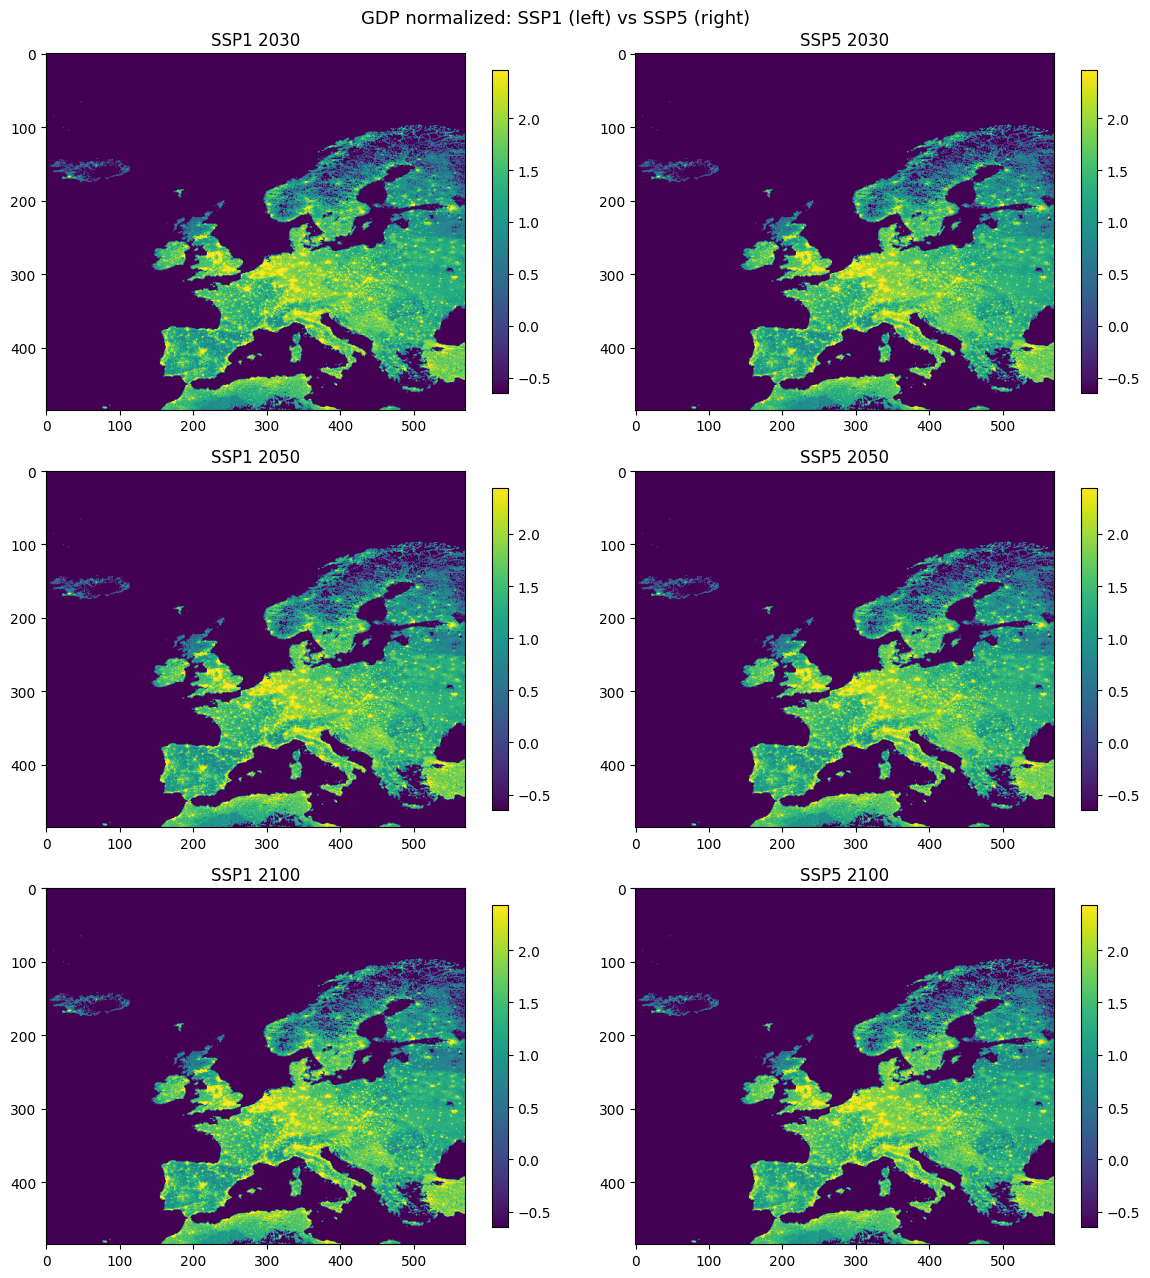

Saved diag_gdp_ssp1_vs_ssp5.png


In [5]:
fig, axes = plt.subplots(3, 2, figsize=(12, 13))
fig.suptitle('GDP normalized: SSP1 (left) vs SSP5 (right)', fontsize=13)

for row, year in enumerate(YEARS):
    g1 = load(f'{NORM_DIR}\\GDP_SSP1_{year}_normalized.tif')
    g5 = load(f'{NORM_DIR}\\GDP_SSP5_{year}_normalized.tif')
    vmin = np.nanpercentile(np.concatenate([g1[~np.isnan(g1)], g5[~np.isnan(g5)]]), 1)
    vmax = np.nanpercentile(np.concatenate([g1[~np.isnan(g1)], g5[~np.isnan(g5)]]), 99)

    for col, (data, title) in enumerate([(g1, f'SSP1 {year}'), (g5, f'SSP5 {year}')]):
        ax = axes[row, col]
        im = ax.imshow(data, cmap='viridis', vmin=vmin, vmax=vmax, origin='upper')
        ax.set_title(title)
        plt.colorbar(im, ax=ax, fraction=0.03)

plt.tight_layout()
plt.savefig('figures/diag_gdp_ssp1_vs_ssp5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved diag_gdp_ssp1_vs_ssp5.png')

## 5. Pixel-level correlation: SSP1 vs SSP5 for GDP and POP

In [6]:
print('Pixel-level Pearson correlation: SSP1 vs SSP5')
print(f'{"Year":<6} {"GDP corr":>12} {"POP corr":>12}')
print('-' * 32)

for year in YEARS:
    g1 = load(f'{NORM_DIR}\\GDP_SSP1_{year}_normalized.tif')
    g5 = load(f'{NORM_DIR}\\GDP_SSP5_{year}_normalized.tif')
    p1 = load(f'{NORM_DIR}\\POP_SSP1_{year}_normalized.tif')
    p5 = load(f'{NORM_DIR}\\POP_SSP5_{year}_normalized.tif')

    gm = ~(np.isnan(g1) | np.isnan(g5))
    pm = ~(np.isnan(p1) | np.isnan(p5))

    gcorr = np.corrcoef(g1[gm], g5[gm])[0, 1]
    pcorr = np.corrcoef(p1[pm], p5[pm])[0, 1]
    print(f'{year:<6} {gcorr:>12.6f} {pcorr:>12.6f}')

print('\nCorrelation near 1.0 = inputs are nearly identical after normalization')

Pixel-level Pearson correlation: SSP1 vs SSP5
Year       GDP corr     POP corr
--------------------------------
2030       0.999971     0.998606
2050       0.999943     0.993748
2100       0.999573     0.991188

Correlation near 1.0 = inputs are nearly identical after normalization


## 6. Difference map: SSP5 minus SSP1 GDP (normalized) — what the model actually sees

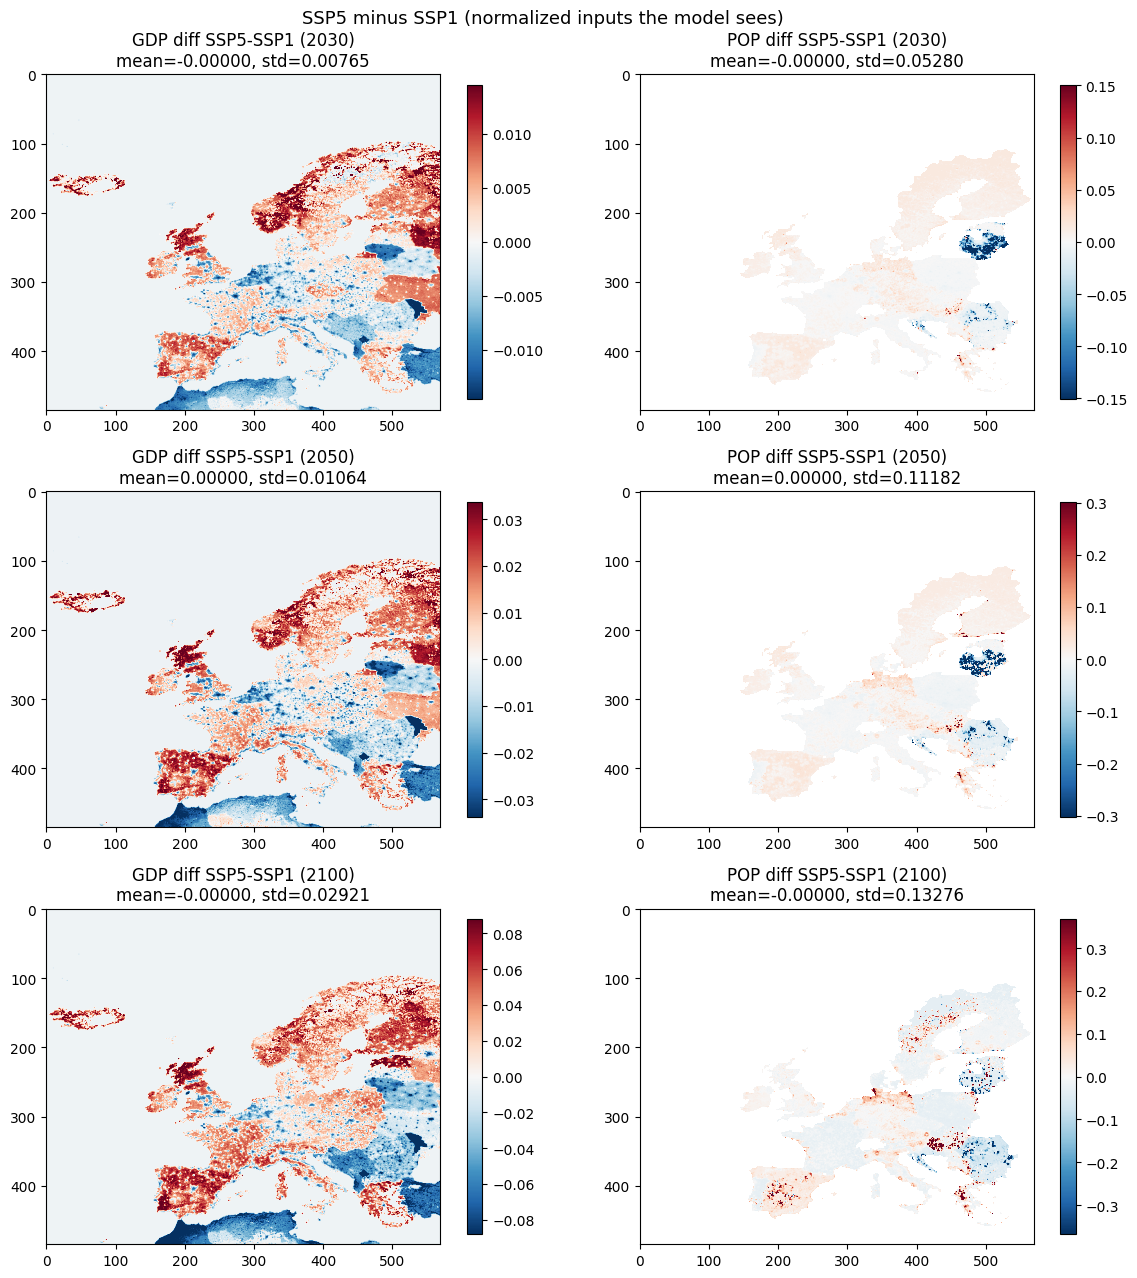

Saved diag_ssp_input_differences.png


In [7]:
fig, axes = plt.subplots(3, 2, figsize=(12, 13))
fig.suptitle('SSP5 minus SSP1 (normalized inputs the model sees)', fontsize=13)

for row, year in enumerate(YEARS):
    g1 = load(f'{NORM_DIR}\\GDP_SSP1_{year}_normalized.tif')
    g5 = load(f'{NORM_DIR}\\GDP_SSP5_{year}_normalized.tif')
    p1 = load(f'{NORM_DIR}\\POP_SSP1_{year}_normalized.tif')
    p5 = load(f'{NORM_DIR}\\POP_SSP5_{year}_normalized.tif')

    for col, (diff, title) in enumerate([
        (g5 - g1, f'GDP diff SSP5-SSP1 ({year})'),
        (p5 - p1, f'POP diff SSP5-SSP1 ({year})'),
    ]):
        ax = axes[row, col]
        dvals = diff[~np.isnan(diff)]
        vabs = max(abs(np.percentile(dvals, 1)), abs(np.percentile(dvals, 99)))
        im = ax.imshow(diff, cmap='RdBu_r', vmin=-vabs, vmax=vabs, origin='upper')
        ax.set_title(f'{title}\nmean={dvals.mean():.5f}, std={dvals.std():.5f}')
        plt.colorbar(im, ax=ax, fraction=0.03)

plt.tight_layout()
plt.savefig('figures/diag_ssp_input_differences.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved diag_ssp_input_differences.png')